# EDA: SADCAT Scoring Results — Figure-Level Analysis

**Corpus:** 6,266 artworks → 19,033 human figures (Qwen2.5-VL-7B-Instruct)  
**Scoring:** SADCAT English dictionary via AGRUPA R package  
**Date:** March 2026

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Config ──
DB_PATH = "/home/agrupa-lab/agrupa/agrupa.sqlite"
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True, parents=True)

# Style
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {"Male": "#6dc985", "Female": "#4f2478", "Unknown": "#888780"}
CTX_COLORS = {"religious": "#660033", "secular": "#B8C4BB"}
DPI = 300

def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    print(f"  Saved: ../figures/{name}.png")

In [2]:
# ── Fixed filter for tipo de objetos (paintings only) ──
KEEP_TIPOS = (
    'Cartón para tapiz',
    'Cuadro Boceto',
    'Cuadro con marco integrado',
    'Díptico',
    'Tríptico',
    'Pequeño retrato',
    'Pintura',
    'Pintura de retablo',
    'Pintura mural',
    'Puerta de sagrario',
)

# ── Load data from SQLite ──
conn = sqlite3.connect(DB_PATH)

placeholders = ','.join(['?'] * len(KEEP_TIPOS))

# All figures with artwork metadata, filtered to valid tipo_objeto
df = pd.read_sql_query(f"""
    SELECT f.*, 
           a.is_religious, a.is_fauna, a.tipo_objeto, a.titulo, a.autor,
           a.century, a.datacion
    FROM figures_m f
    JOIN artwork a ON f.cat_no = a.cat_no
    WHERE a.tipo_objeto IN ({placeholders})
""", conn, params=KEEP_TIPOS)

# Captions table (also filtered)
captions = pd.read_sql_query(f"""
    SELECT c.*
    FROM qwen_captions_m c
    JOIN artwork a ON c.cat_no = a.cat_no
    WHERE a.tipo_objeto IN ({placeholders})
""", conn, params=KEEP_TIPOS)
conn.close()

print(f"Total figures (filtered by tipo_objeto): {len(df)}")
print(f"Unique artworks: {df['cat_no'].nunique()}")
print(f"Captions: {len(captions)}")
print(f"Tipo objetos included: {', '.join(KEEP_TIPOS[:3])}... ({len(KEEP_TIPOS)} types)")
df.head()

Total figures (filtered by tipo_objeto): 19033
Unique artworks: 6093
Captions: 6266
Tipo objetos included: Cartón para tapiz, Cuadro Boceto, Cuadro con marco integrado... (10 types)


,id,cat_no,context,figure_num,gender,qualifier,descriptor_text,descriptor_length,word_count,n_descriptors,...,asymmetry,model_id,created_at,is_religious,is_fauna,tipo_objeto,titulo,autor,century,datacion
0,1,P000001,secular,1,Female,NaN,The central female figure is reclining on a re...,370,61,30,...,0.166667,Qwen/Qwen2.5-VL-7B-Instruct,2026-03-15 13:19:17,0,0,Pintura,El tocador de Venus,"Albani, Francesco",17th c.,1635 - 1640
1,2,P000001,secular,2,Female,NaN,"To the left of the central figure, another wom...",307,55,24,...,-0.357143,Qwen/Qwen2.5-VL-7B-Instruct,2026-03-15 13:19:17,0,0,Pintura,El tocador de Venus,"Albani, Francesco",17th c.,1635 - 1640
2,3,P000001,secular,3,Female,NaN,"A third woman, positioned behind the central f...",327,53,24,...,-0.100000,Qwen/Qwen2.5-VL-7B-Instruct,2026-03-15 13:19:17,0,0,Pintura,El tocador de Venus,"Albani, Francesco",17th c.,1635 - 1640
3,4,P000001,secular,4,Male,NaN,"On the far right, a male figure is perched ato...",317,58,21,...,-0.500000,Qwen/Qwen2.5-VL-7B-Instruct,2026-03-15 13:19:17,0,0,Pintura,El tocador de Venus,"Albani, Francesco",17th c.,1635 - 1640
4,5,P000001,secular,5,Male,NaN,"Another male figure, located near the center-l...",353,61,27,...,-0.605556,Qwen/Qwen2.5-VL-7B-Instruct,2026-03-15 13:19:17,0,0,Pintura,El tocador de Venus,"Albani, Francesco",17th c.,1635 - 1640


In [3]:
# Save analysis-ready dataset for local work
dfa = df.copy()
dfa.to_csv("../caption_outputs/analysis_dataset.csv", index=False)
print(f"Saved {len(dfa)} figures to caption_outputs/analysis_dataset.csv")

Saved 19033 figures to caption_outputs/analysis_dataset.csv


## 1. Pipeline Quality: Coverage & Scoring Diagnostics

  Saved: ../figures/07_pipeline_diagnostics.png


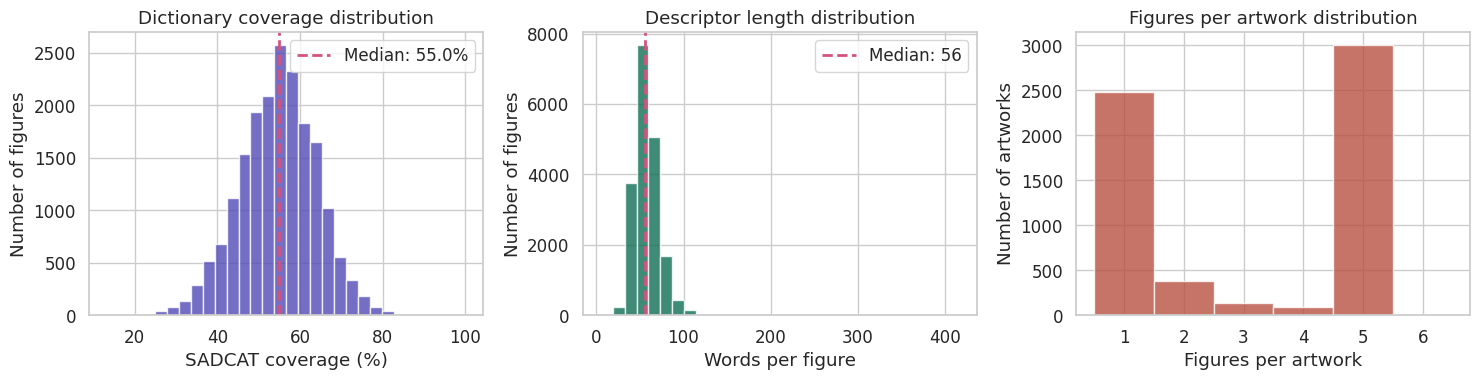


Coverage stats:
  Mean: 54.7%
  Median: 55.0%
  Min: 13.3%
  Figures with 0%: 0
  Figures w/ warmth score: 18088
  Figures w/ competence score: 18976


In [4]:
# ── 1a. SADCAT coverage distribution ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Coverage histogram
axes[0].hist(df["coverage_pct"].dropna(), bins=30, color="#534AB7", alpha=0.8, edgecolor="white")
axes[0].axvline(df["coverage_pct"].median(), color="#D4537E", ls="--", lw=2, label=f"Median: {df['coverage_pct'].median():.1f}%")
axes[0].set_xlabel("SADCAT coverage (%)")
axes[0].set_ylabel("Number of figures")
axes[0].set_title("Dictionary coverage distribution")
axes[0].legend()

# Words per figure
axes[1].hist(df["word_count"].dropna(), bins=30, color="#0F6E56", alpha=0.8, edgecolor="white")
axes[1].axvline(df["word_count"].median(), color="#D4537E", ls="--", lw=2, label=f"Median: {df['word_count'].median():.0f}")
axes[1].set_xlabel("Words per figure")
axes[1].set_ylabel("Number of figures")
axes[1].set_title("Descriptor length distribution")
axes[1].legend()

# Figures per artwork
figs_per_art = df.groupby("cat_no").size()
axes[2].hist(figs_per_art, bins=range(1, figs_per_art.max()+2), color="#B85042", alpha=0.8, edgecolor="white", align="left")
axes[2].set_xlabel("Figures per artwork")
axes[2].set_ylabel("Number of artworks")
axes[2].set_title("Figures per artwork distribution")
axes[2].set_xticks(range(1, min(figs_per_art.max()+1, 8)))

plt.tight_layout()
savefig(fig, "07_pipeline_diagnostics")
plt.show()

print(f"\nCoverage stats:")
print(f"  Mean: {df['coverage_pct'].mean():.1f}%")
print(f"  Median: {df['coverage_pct'].median():.1f}%")
print(f"  Min: {df['coverage_pct'].min():.1f}%")
print(f"  Figures with 0%: {(df['coverage_pct'] == 0).sum()}")
print(f"  Figures w/ warmth score: {df['dirmean_Warmth'].notna().sum()}")
print(f"  Figures w/ competence score: {df['dirmean_Competence'].notna().sum()}")

  Saved: ../figures/07b_coverage_by_context_gender.png


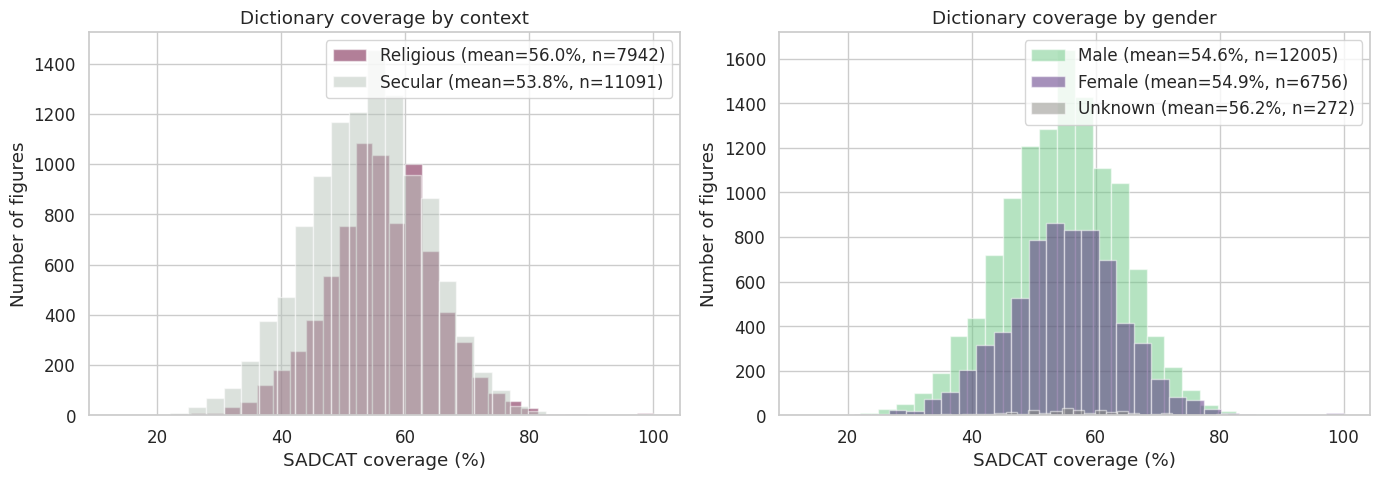

Coverage by context:
  religious: mean=56.0%, median=56.0%, n=7942
  secular: mean=53.8%, median=54.2%, n=11091
  Mann-Whitney U: U=49970480, p=0.0000

Coverage by gender:
  Male: mean=54.6%, median=54.8%, n=12005
  Female: mean=54.9%, median=55.0%, n=6756
  Unknown: mean=56.2%, median=56.2%, n=272
  Male vs Female Mann-Whitney U: U=39938485, p=0.0844


In [5]:
# -- 1b. Coverage by context and gender (pipeline bias check) --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage by context
for ctx, color in CTX_COLORS.items():
    sub = df[df["context"] == ctx]["coverage_pct"].dropna()
    axes[0].hist(sub, bins=30, alpha=0.5, label=f"{ctx.capitalize()} (mean={sub.mean():.1f}%, n={len(sub)})",
               color=color, edgecolor="white")
axes[0].set_xlabel("SADCAT coverage (%)")
axes[0].set_ylabel("Number of figures")
axes[0].set_title("Dictionary coverage by context")
axes[0].legend()

# Coverage by gender
for g in ["Male", "Female", "Unknown"]:
    sub = df[df["gender"] == g]["coverage_pct"].dropna()
    axes[1].hist(sub, bins=30, alpha=0.5, label=f"{g} (mean={sub.mean():.1f}%, n={len(sub)})",
               color=COLORS.get(g, "#888888"), edgecolor="white")
axes[1].set_xlabel("SADCAT coverage (%)")
axes[1].set_ylabel("Number of figures")
axes[1].set_title("Dictionary coverage by gender")
axes[1].legend()

plt.tight_layout()
savefig(fig, "07b_coverage_by_context_gender")
plt.show()

# Statistical comparison
from scipy import stats
print("Coverage by context:")
for ctx in ["religious", "secular"]:
    sub = df[df["context"] == ctx]["coverage_pct"].dropna()
    print(f"  {ctx}: mean={sub.mean():.1f}%, median={sub.median():.1f}%, n={len(sub)}")
rel = df[df["context"]=="religious"]["coverage_pct"].dropna()
sec = df[df["context"]=="secular"]["coverage_pct"].dropna()
stat, p = stats.mannwhitneyu(rel, sec, alternative="two-sided")
print(f"  Mann-Whitney U: U={stat:.0f}, p={p:.4f}")

print("\nCoverage by gender:")
for g in ["Male", "Female", "Unknown"]:
    sub = df[df["gender"] == g]["coverage_pct"].dropna()
    print(f"  {g}: mean={sub.mean():.1f}%, median={sub.median():.1f}%, n={len(sub)}")
male_cov = df[df["gender"]=="Male"]["coverage_pct"].dropna()
female_cov = df[df["gender"]=="Female"]["coverage_pct"].dropna()
stat, p = stats.mannwhitneyu(male_cov, female_cov, alternative="two-sided")
print(f"  Male vs Female Mann-Whitney U: U={stat:.0f}, p={p:.4f}")


## 2. Corpus Composition: Gender & Context

In [6]:
# Filter to Male/Female only for analysis
dfa = df[df["gender"].isin(["Male", "Female"])].copy()
print(f"Analysis set (Male + Female only): {len(dfa)} figures")
print(f"Dropped Unknown: {len(df) - len(dfa)}")

Analysis set (Male + Female only): 18761 figures
Dropped Unknown: 272


  Saved: ../figures/08_gender_context_composition.png


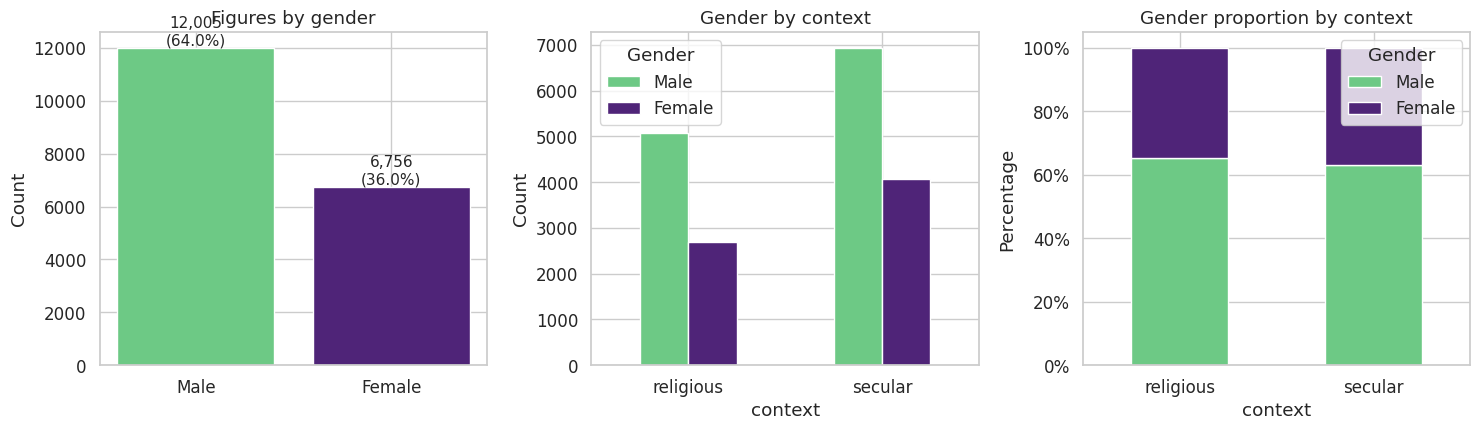

In [7]:
# ── 2a. Gender counts overall and by context ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Overall gender
gender_counts = dfa["gender"].value_counts()
bars = axes[0].bar(gender_counts.index, gender_counts.values,
                   color=[COLORS[g] for g in gender_counts.index], edgecolor="white")
for bar, val in zip(bars, gender_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f"{val:,}\n({val/len(dfa)*100:.1f}%)", ha="center", fontsize=11)
axes[0].set_title("Figures by gender")
axes[0].set_ylabel("Count")

# Gender by context
ct = pd.crosstab(dfa["context"], dfa["gender"])
ct[["Male", "Female"]].plot(kind="bar", ax=axes[1], color=[COLORS["Male"], COLORS["Female"]],
                             edgecolor="white", rot=0)
axes[1].set_title("Gender by context")
axes[1].set_ylabel("Count")
axes[1].legend(title="Gender")

# Gender ratio by context
ratio = ct.div(ct.sum(axis=1), axis=0) * 100
ratio[["Male", "Female"]].plot(kind="bar", stacked=True, ax=axes[2],
                                color=[COLORS["Male"], COLORS["Female"]],
                                edgecolor="white", rot=0)
axes[2].set_title("Gender proportion by context")
axes[2].set_ylabel("Percentage")
axes[2].legend(title="Gender")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
savefig(fig, "08_gender_context_composition")
plt.show()

## 3. Warmth, Competence & Asymmetry: Overall Gender Comparison

  Saved: ../figures/09_warmth_competence_distributions.png


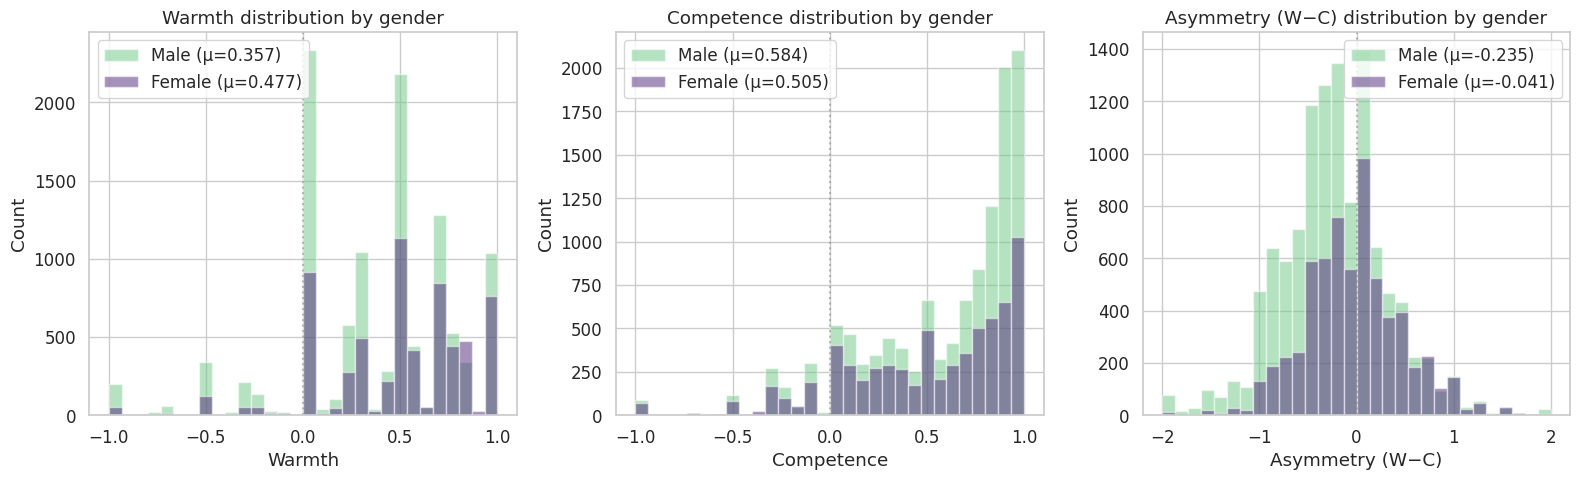

In [8]:
# ── 3a. Warmth & Competence distributions by gender ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (dim, title) in enumerate([("dirmean_Warmth", "Warmth"),
                                    ("dirmean_Competence", "Competence"),
                                    ("asymmetry", "Asymmetry (W−C)")]):
    for g in ["Male", "Female"]:
        sub = dfa[dfa["gender"] == g][dim].dropna()
        axes[i].hist(sub, bins=30, alpha=0.5, label=f"{g} (μ={sub.mean():.3f})",
                    color=COLORS[g], edgecolor="white")
    axes[i].set_xlabel(title)
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"{title} distribution by gender")
    axes[i].legend()
    axes[i].axvline(0, color="gray", ls=":", alpha=0.5)

plt.tight_layout()
savefig(fig, "09_warmth_competence_distributions")
plt.show()

/tmp/ipykernel_238222/1539035547.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfa, x="gender", y=dim, ax=axes[i],
/tmp/ipykernel_238222/1539035547.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfa, x="gender", y=dim, ax=axes[i],
/tmp/ipykernel_238222/1539035547.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfa, x="gender", y=dim, ax=axes[i],


  Saved: ../figures/10_wc_boxplots_gender.png


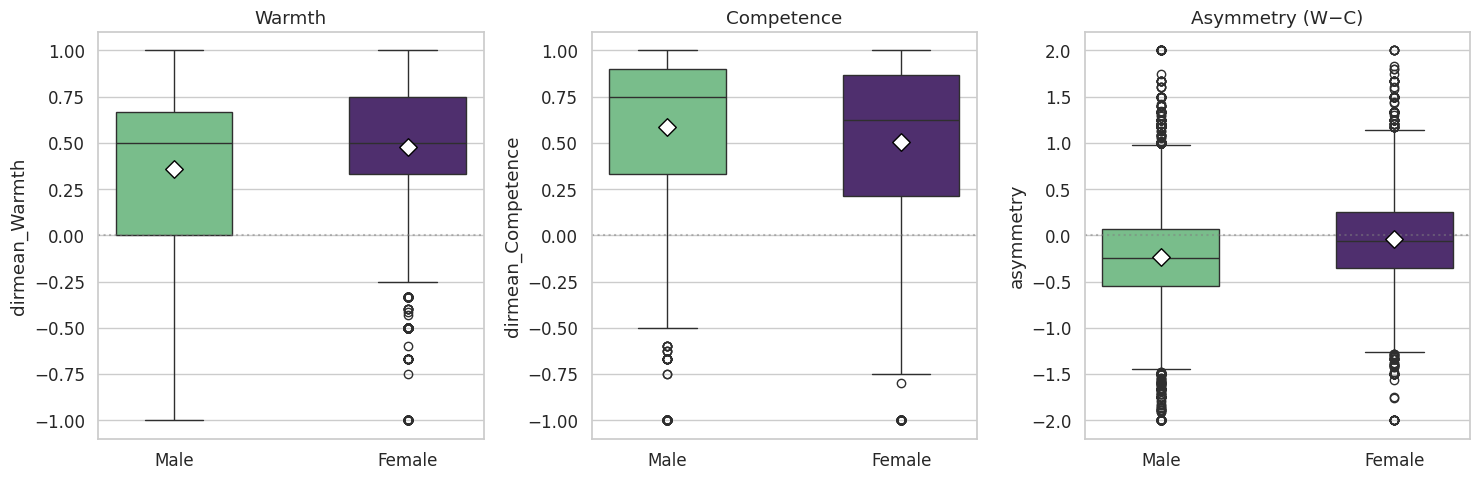

In [9]:
# ── 3b. Box plots: Warmth, Competence, Asymmetry by gender ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (dim, title) in enumerate([("dirmean_Warmth", "Warmth"),
                                    ("dirmean_Competence", "Competence"),
                                    ("asymmetry", "Asymmetry (W−C)")]):
    sns.boxplot(data=dfa, x="gender", y=dim, ax=axes[i],
               palette=COLORS, order=["Male", "Female"], width=0.5)
    axes[i].set_title(title)
    axes[i].set_xlabel("")
    axes[i].axhline(0, color="gray", ls=":", alpha=0.5)
    
    # Add means
    for j, g in enumerate(["Male", "Female"]):
        mean_val = dfa[dfa["gender"]==g][dim].mean()
        axes[i].scatter(j, mean_val, color="white", edgecolor="black", s=80, zorder=5, marker="D")

plt.tight_layout()
savefig(fig, "10_wc_boxplots_gender")
plt.show()

/tmp/ipykernel_238222/4118762327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dfa, x="gender", y=dim, ax=axes[i],
/tmp/ipykernel_238222/4118762327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dfa, x="gender", y=dim, ax=axes[i],
/tmp/ipykernel_238222/4118762327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dfa, x="gender", y=dim, ax=axes[i],


  Saved: ../figures/10b_wc_violins_gender.png


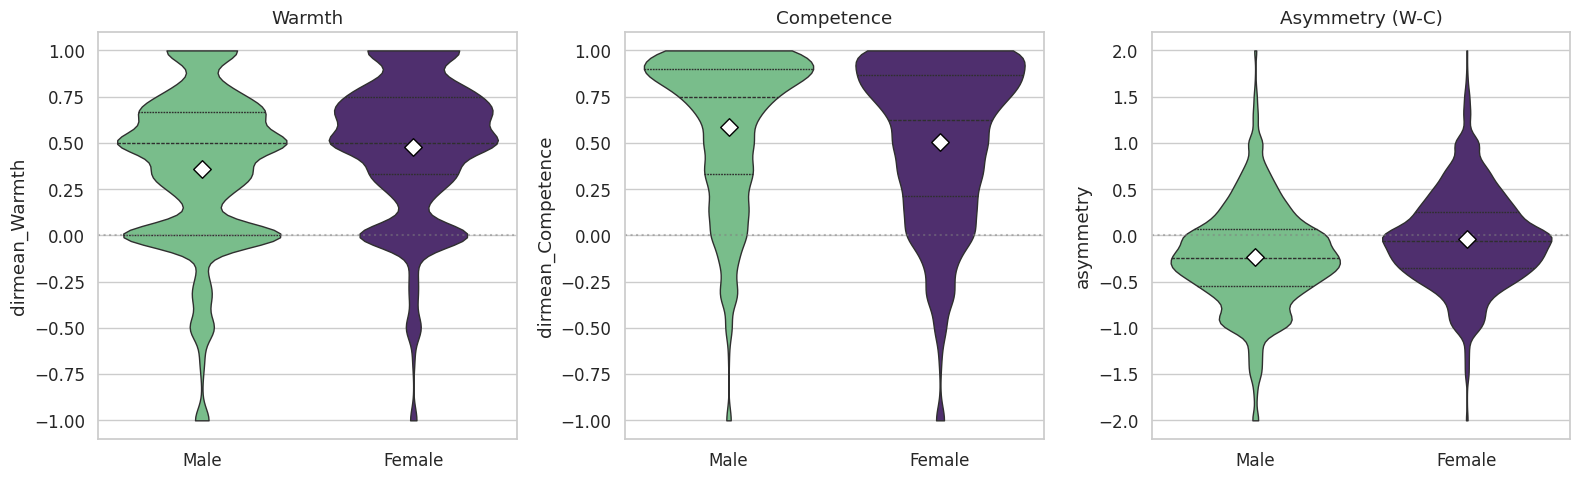

In [10]:
# -- 3b2. Violin plots: Warmth, Competence, Asymmetry by gender --
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (dim, title) in enumerate([("dirmean_Warmth", "Warmth"),
                                    ("dirmean_Competence", "Competence"),
                                    ("asymmetry", "Asymmetry (W-C)")]):
    sns.violinplot(data=dfa, x="gender", y=dim, ax=axes[i],
                  palette=COLORS, order=["Male", "Female"], inner="quartile",
                  cut=0, linewidth=1)
    axes[i].set_title(title)
    axes[i].set_xlabel("")
    axes[i].axhline(0, color="gray", ls=":", alpha=0.5)
    
    # Add means
    for j, g in enumerate(["Male", "Female"]):
        mean_val = dfa[dfa["gender"]==g][dim].mean()
        axes[i].scatter(j, mean_val, color="white", edgecolor="black", s=80, zorder=5, marker="D")

plt.tight_layout()
savefig(fig, "10b_wc_violins_gender")
plt.show()


In [11]:
# -- 3d. Effect sizes: Cohen's d and statistical tests for gender comparisons --
from scipy import stats

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    var1, var2 = g1.var(), g2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std

print("Effect sizes: Gender comparisons (Male vs Female)")
print("=" * 70)

for dim, title in [("dirmean_Warmth", "Warmth"), ("dirmean_Competence", "Competence"),
                    ("asymmetry", "Asymmetry (W-C)")]:
    male = dfa[dfa["gender"]=="Male"][dim].dropna()
    female = dfa[dfa["gender"]=="Female"][dim].dropna()
    
    d = cohens_d(female, male)
    t_stat, t_p = stats.ttest_ind(female, male, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(female, male, alternative="two-sided")
    
    print(f"\n{title}:")
    print(f"  Male:   mean={male.mean():.4f}, sd={male.std():.4f}, n={len(male)}")
    print(f"  Female: mean={female.mean():.4f}, sd={female.std():.4f}, n={len(female)}")
    print(f"  Cohen's d (F-M): {d:+.4f}")
    print(f"  Welch's t: t={t_stat:.3f}, p={t_p:.2e}")
    print(f"  Mann-Whitney U: U={u_stat:.0f}, p={u_p:.2e}")


Effect sizes: Gender comparisons (Male vs Female)

Warmth:
  Male:   mean=0.3568, sd=0.4184, n=11344
  Female: mean=0.4771, sd=0.3773, n=6482
  Cohen's d (F-M): +0.2978
  Welch's t: t=19.669, p=4.97e-85
  Mann-Whitney U: U=43287591, p=5.14e-88

Competence:
  Male:   mean=0.5835, sd=0.4106, n=11992
  Female: mean=0.5048, sd=0.4299, n=6712
  Cohen's d (F-M): -0.1884
  Welch's t: t=-12.199, p=4.79e-34
  Mann-Whitney U: U=35594879, p=1.66e-39

Asymmetry (W-C):
  Male:   mean=-0.2347, sd=0.5492, n=11333
  Female: mean=-0.0407, sd=0.5105, n=6440
  Cohen's d (F-M): +0.3622
  Welch's t: t=23.681, p=1.27e-121
  Mann-Whitney U: U=44264792, p=1.30e-123


In [12]:
# ── 3c. Summary statistics table ──
summary = dfa.groupby("gender").agg(
    n=("cat_no", "count"),
    warmth_mean=("dirmean_Warmth", "mean"),
    warmth_std=("dirmean_Warmth", "std"),
    competence_mean=("dirmean_Competence", "mean"),
    competence_std=("dirmean_Competence", "std"),
    asymmetry_mean=("asymmetry", "mean"),
    asymmetry_std=("asymmetry", "std"),
    coverage_mean=("coverage_pct", "mean"),
).round(3)
print("Gender summary:")
summary

Gender summary:


,n,warmth_mean,warmth_std,competence_mean,competence_std,asymmetry_mean,asymmetry_std,coverage_mean
gender,,,,,,,,
Female,6756,0.477,0.377,0.505,0.430,-0.041,0.511,54.882
Male,12005,0.357,0.418,0.584,0.411,-0.235,0.549,54.582


## 4. Religious vs Secular: Context × Gender Interaction (H2 preview)

     context  gender     n  warmth  competence  asymmetry
0  religious  Female  2683   0.536       0.528     -0.002
1  religious    Male  5067   0.408       0.535     -0.135
2    secular  Female  4073   0.438       0.489     -0.067
3    secular    Male  6938   0.319       0.619     -0.308
  Saved: ../figures/11_context_gender_bars.png


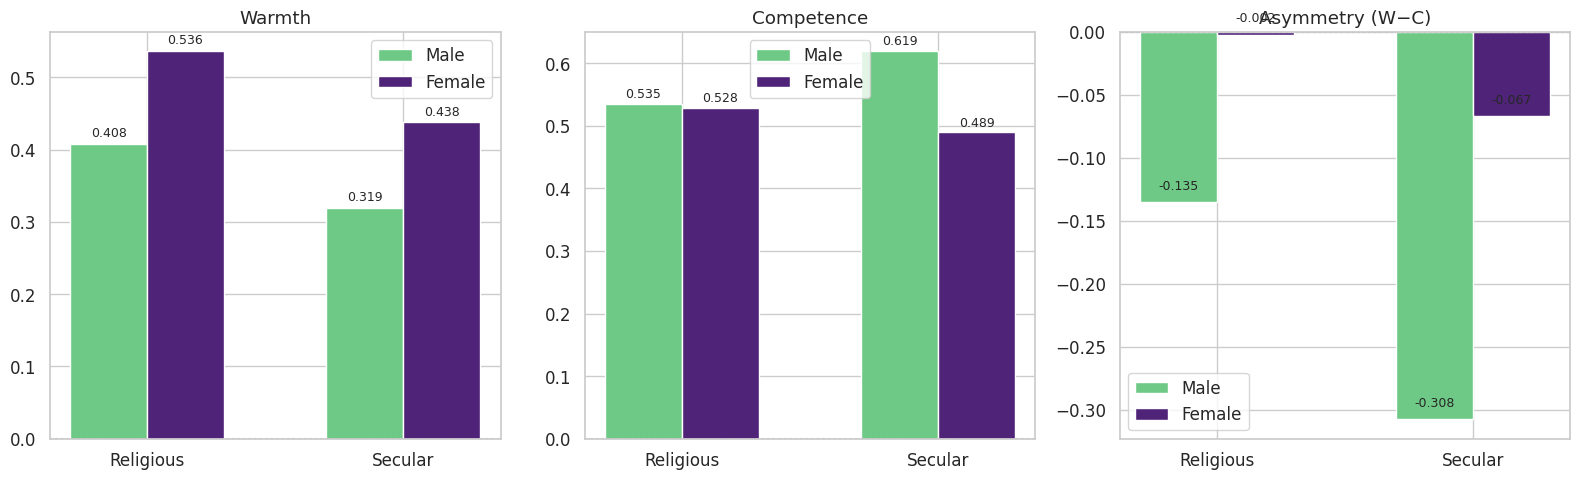

In [13]:
# ── 4a. Grouped bar chart: W, C, Asymmetry by context × gender ──
ctx_gender = dfa.groupby(["context", "gender"]).agg(
    n=("cat_no", "count"),
    warmth=("dirmean_Warmth", "mean"),
    competence=("dirmean_Competence", "mean"),
    asymmetry=("asymmetry", "mean"),
).reset_index()
print(ctx_gender.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, title) in enumerate([("warmth", "Warmth"), ("competence", "Competence"), ("asymmetry", "Asymmetry (W−C)")]):
    x = np.arange(2)
    w = 0.3
    for j, g in enumerate(["Male", "Female"]):
        vals = ctx_gender[ctx_gender["gender"]==g][col].values
        bars = axes[i].bar(x + j*w, vals, w, label=g, color=COLORS[g], edgecolor="white")
        for bar, val in zip(bars, vals):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f"{val:.3f}", ha="center", fontsize=9)
    axes[i].set_xticks(x + w/2)
    axes[i].set_xticklabels(["Religious", "Secular"])
    axes[i].set_title(title)
    axes[i].legend()
    axes[i].axhline(0, color="gray", ls=":", alpha=0.5)

plt.tight_layout()
savefig(fig, "11_context_gender_bars")
plt.show()

  Saved: ../figures/12_asymmetry_context_gender_box.png


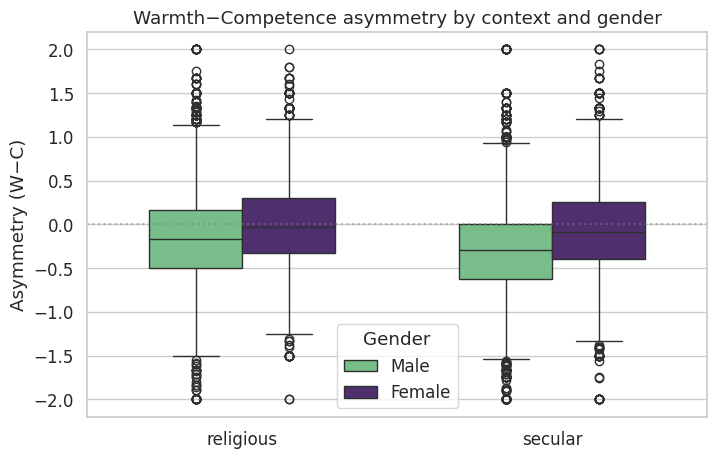

In [14]:
# ── 4b. Box plots: Asymmetry by context × gender ──
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=dfa, x="context", y="asymmetry", hue="gender",
           palette=COLORS, hue_order=["Male", "Female"],
           order=["religious", "secular"], width=0.6, ax=ax)
ax.set_title("Warmth−Competence asymmetry by context and gender")
ax.set_xlabel("")
ax.set_ylabel("Asymmetry (W−C)")
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.legend(title="Gender")

savefig(fig, "12_asymmetry_context_gender_box")
plt.show()

  Saved: ../figures/12b_interaction_plot_context_gender.png


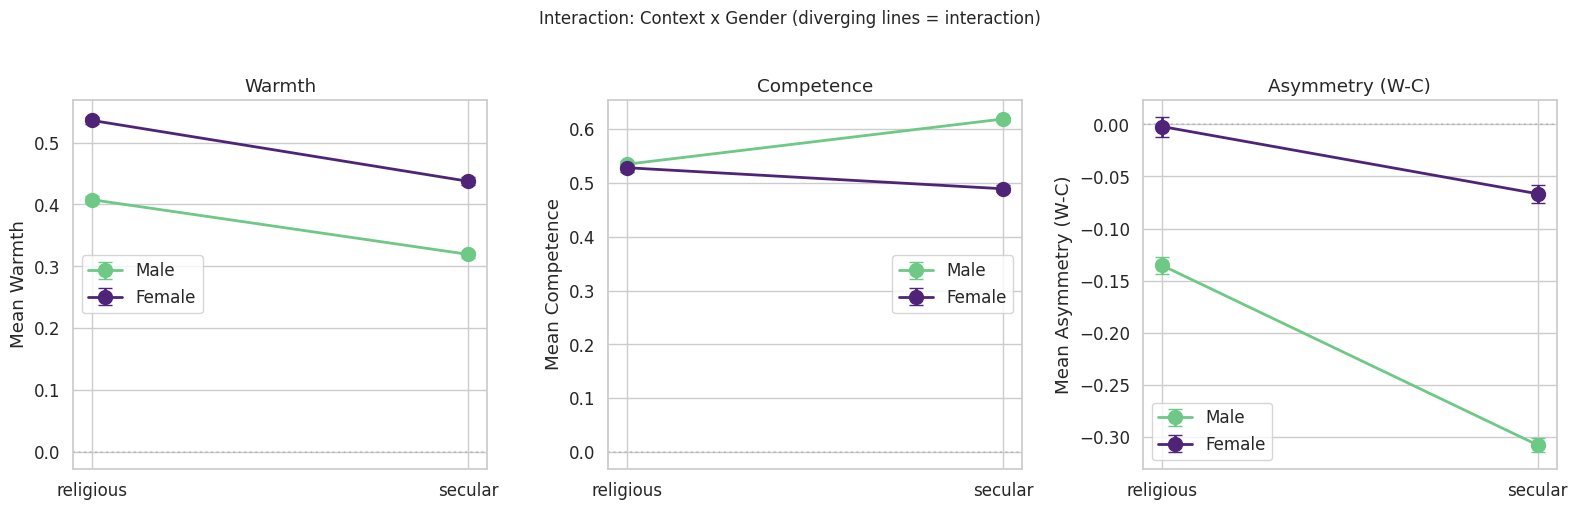

In [15]:
# -- 4c. Interaction plot: context x gender on W, C, asymmetry --
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, title) in enumerate([("dirmean_Warmth", "Warmth"),
                                   ("dirmean_Competence", "Competence"),
                                   ("asymmetry", "Asymmetry (W-C)")]):
    for g in ["Male", "Female"]:
        means = dfa[dfa["gender"]==g].groupby("context")[col].mean()
        sems = dfa[dfa["gender"]==g].groupby("context")[col].sem()
        x_order = ["religious", "secular"]
        y_vals = [means.get(c, np.nan) for c in x_order]
        y_err = [sems.get(c, 0) for c in x_order]
        axes[i].errorbar(x_order, y_vals, yerr=y_err, marker="o", lw=2,
                        markersize=10, capsize=5, color=COLORS[g], label=g)
    axes[i].set_title(title)
    axes[i].set_ylabel(f"Mean {title}")
    axes[i].set_xlabel("")
    axes[i].legend()
    axes[i].axhline(0, color="gray", ls=":", alpha=0.3)

fig.suptitle("Interaction: Context x Gender (diverging lines = interaction)", fontsize=12, y=1.02)
plt.tight_layout()
savefig(fig, "12b_interaction_plot_context_gender")
plt.show()


## 5. Within-Artwork Gender Comparison: Paired Figures

In [16]:
# ── 5a. Identify artworks with both male AND female figures ──
artwork_genders = dfa.groupby("cat_no")["gender"].apply(set).reset_index()
artwork_genders["has_both"] = artwork_genders["gender"].apply(lambda s: "Male" in s and "Female" in s)

both_cat_nos = artwork_genders[artwork_genders["has_both"]]["cat_no"]
df_both = dfa[dfa["cat_no"].isin(both_cat_nos)].copy()

print(f"Artworks with both M and F figures: {len(both_cat_nos)} ({len(both_cat_nos)/dfa['cat_no'].nunique()*100:.1f}% of artworks)")
print(f"Figures in mixed-gender artworks: {len(df_both)}")
print(f"  Male: {(df_both['gender']=='Male').sum()}")
print(f"  Female: {(df_both['gender']=='Female').sum()}")

Artworks with both M and F figures: 2833 (46.5% of artworks)
Figures in mixed-gender artworks: 13054
  Male: 7550
  Female: 5504


In [17]:
# ── 5b. Within-artwork mean scores: male vs female in SAME painting ──
within_scores = df_both.groupby(["cat_no", "gender"]).agg(
    warmth=("dirmean_Warmth", "mean"),
    competence=("dirmean_Competence", "mean"),
    asymmetry=("asymmetry", "mean"),
).reset_index()

# Pivot to get male and female side by side per artwork
within_wide = within_scores.pivot(index="cat_no", columns="gender", values=["warmth", "competence", "asymmetry"])
within_wide.columns = [f"{dim}_{gen}" for dim, gen in within_wide.columns]
within_wide = within_wide.dropna().reset_index()

print(f"Artworks with complete paired scores: {len(within_wide)}")
print(f"\nWithin-artwork means:")
print(f"  Male warmth:   {within_wide['warmth_Male'].mean():.3f}")
print(f"  Female warmth: {within_wide['warmth_Female'].mean():.3f}")
print(f"  Male competence:   {within_wide['competence_Male'].mean():.3f}")
print(f"  Female competence: {within_wide['competence_Female'].mean():.3f}")
print(f"  Male asymmetry:   {within_wide['asymmetry_Male'].mean():.3f}")
print(f"  Female asymmetry: {within_wide['asymmetry_Female'].mean():.3f}")

Artworks with complete paired scores: 2720

Within-artwork means:
  Male warmth:   0.360
  Female warmth: 0.493
  Male competence:   0.539
  Female competence: 0.489
  Male asymmetry:   -0.182
  Female asymmetry: -0.002


  Saved: ../figures/13_within_artwork_scatter.png


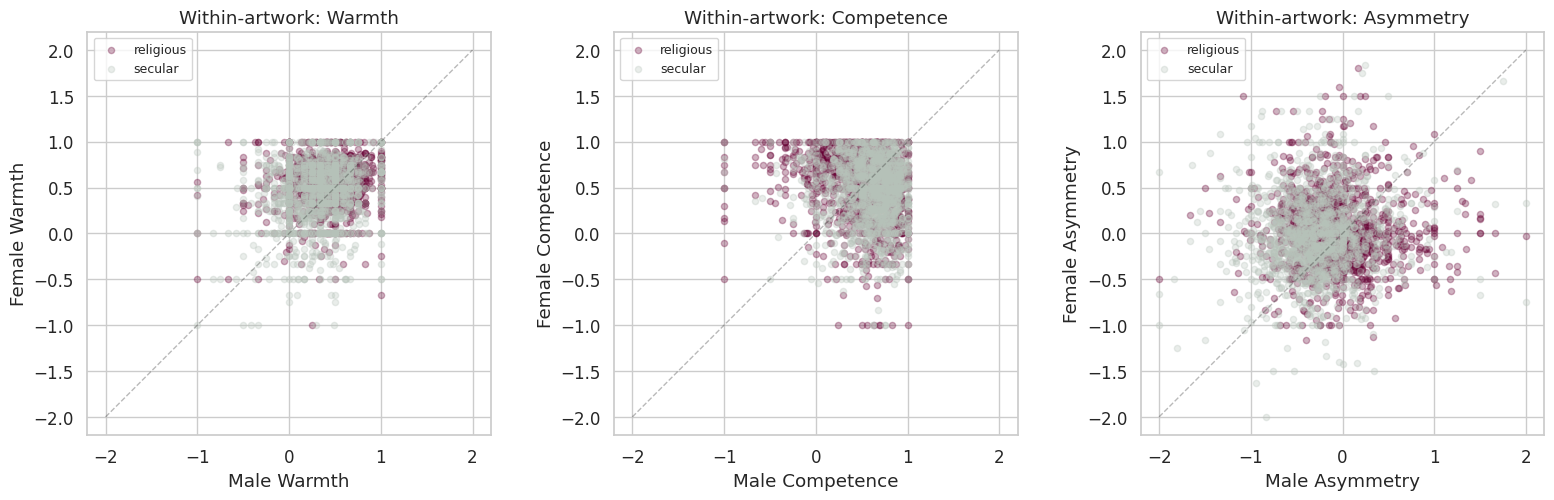


Within-artwork patterns:
  Female warmer than Male: 62.6%
  Male more competent than Female: 54.6%
  Female higher asymmetry (W-C) than Male: 62.5%


In [18]:
# ── 5c. Scatter: Female vs Male warmth/competence within same artwork ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (dim, title) in enumerate([("warmth", "Warmth"), ("competence", "Competence"), ("asymmetry", "Asymmetry")]):
    m_col = f"{dim}_Male"
    f_col = f"{dim}_Female"
    
    # Add context color
    within_ctx = within_wide.merge(dfa[["cat_no", "context"]].drop_duplicates(), on="cat_no")
    
    for ctx, color in CTX_COLORS.items():
        sub = within_ctx[within_ctx["context"] == ctx]
        axes[i].scatter(sub[m_col], sub[f_col], alpha=0.3, s=20, color=color, label=ctx)
    
    # Diagonal line (equal)
    lims = [-2, 2]
    axes[i].plot(lims, lims, "k--", alpha=0.3, lw=1)
    axes[i].set_xlabel(f"Male {title}")
    axes[i].set_ylabel(f"Female {title}")
    axes[i].set_title(f"Within-artwork: {title}")
    axes[i].legend(fontsize=9)
    axes[i].set_aspect("equal")

plt.tight_layout()
savefig(fig, "13_within_artwork_scatter")
plt.show()

# Stats: how often is female warmer than male in same painting?
print(f"\nWithin-artwork patterns:")
print(f"  Female warmer than Male: {(within_wide['warmth_Female'] > within_wide['warmth_Male']).mean()*100:.1f}%")
print(f"  Male more competent than Female: {(within_wide['competence_Male'] > within_wide['competence_Female']).mean()*100:.1f}%")
print(f"  Female higher asymmetry (W-C) than Male: {(within_wide['asymmetry_Female'] > within_wide['asymmetry_Male']).mean()*100:.1f}%")

  Saved: ../figures/14_within_artwork_paired_diff.png


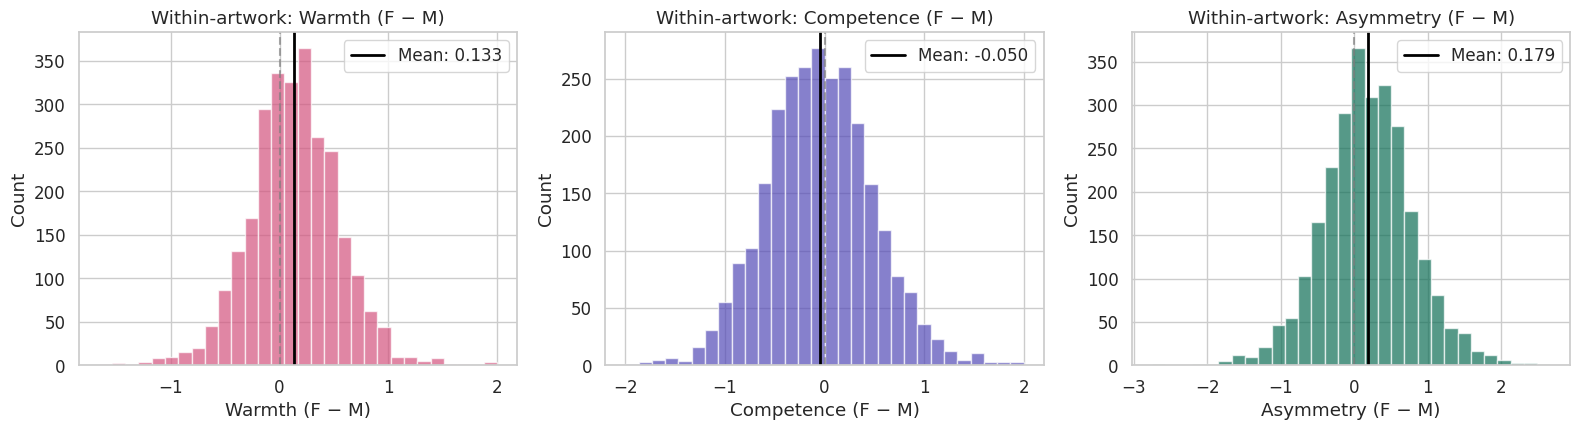

In [19]:
# ── 5d. Within-artwork paired difference distribution ──
within_wide["warmth_diff"] = within_wide["warmth_Female"] - within_wide["warmth_Male"]
within_wide["competence_diff"] = within_wide["competence_Female"] - within_wide["competence_Male"]
within_wide["asymmetry_diff"] = within_wide["asymmetry_Female"] - within_wide["asymmetry_Male"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, (col, title, color) in enumerate([
    ("warmth_diff", "Warmth (F − M)", "#D4537E"),
    ("competence_diff", "Competence (F − M)", "#534AB7"),
    ("asymmetry_diff", "Asymmetry (F − M)", "#0F6E56"),
]):
    vals = within_wide[col].dropna()
    axes[i].hist(vals, bins=30, color=color, alpha=0.7, edgecolor="white")
    axes[i].axvline(0, color="gray", ls="--", alpha=0.7)
    axes[i].axvline(vals.mean(), color="black", ls="-", lw=2, label=f"Mean: {vals.mean():.3f}")
    axes[i].set_xlabel(title)
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"Within-artwork: {title}")
    axes[i].legend()

plt.tight_layout()
savefig(fig, "14_within_artwork_paired_diff")
plt.show()

  Saved: ../figures/14b_within_artwork_paired_by_context.png


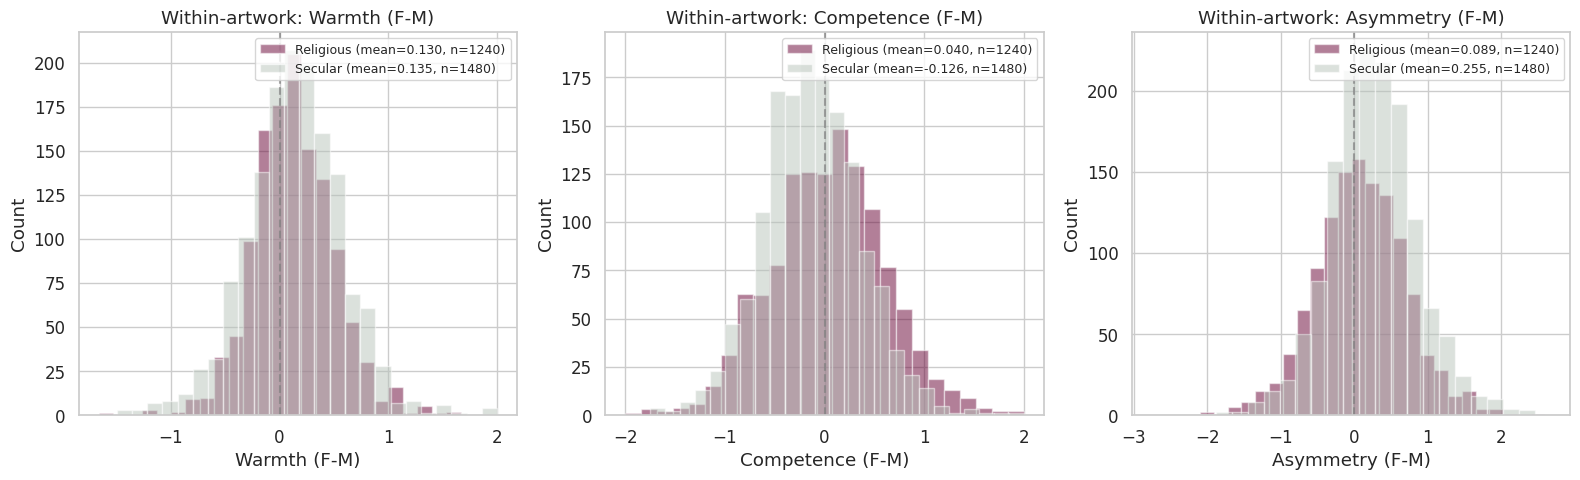

Warmth within-artwork (F-M): religious mean=0.1299, secular mean=0.1354, Welch t=-0.351, p=0.7256
Competence within-artwork (F-M): religious mean=0.0399, secular mean=-0.1258, Welch t=8.011, p=0.0000
Asymmetry within-artwork (F-M): religious mean=0.0893, secular mean=0.2548, Welch t=-7.026, p=0.0000


In [20]:
# -- 5e. Within-artwork paired difference: religious vs secular --
within_ctx = within_wide.merge(dfa[["cat_no", "context"]].drop_duplicates(), on="cat_no")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, title) in enumerate([
    ("warmth_diff", "Warmth (F-M)"),
    ("competence_diff", "Competence (F-M)"),
    ("asymmetry_diff", "Asymmetry (F-M)"),
]):
    for ctx in ["religious", "secular"]:
        sub = within_ctx[within_ctx["context"]==ctx][col].dropna()
        axes[i].hist(sub, bins=25, alpha=0.5, label=f"{ctx.capitalize()} (mean={sub.mean():.3f}, n={len(sub)})",
                    color=CTX_COLORS[ctx], edgecolor="white")
    axes[i].axvline(0, color="gray", ls="--", alpha=0.7)
    axes[i].set_xlabel(title)
    axes[i].set_ylabel("Count")
    axes[i].set_title(f"Within-artwork: {title}")
    axes[i].legend(fontsize=9)

plt.tight_layout()
savefig(fig, "14b_within_artwork_paired_by_context")
plt.show()

# Stats: is the within-painting gender gap larger in religious artworks?
from scipy import stats
for col, title in [("warmth_diff", "Warmth"), ("competence_diff", "Competence"), ("asymmetry_diff", "Asymmetry")]:
    rel = within_ctx[within_ctx["context"]=="religious"][col].dropna()
    sec = within_ctx[within_ctx["context"]=="secular"][col].dropna()
    t_stat, t_p = stats.ttest_ind(rel, sec, equal_var=False)
    print(f"{title} within-artwork (F-M): religious mean={rel.mean():.4f}, secular mean={sec.mean():.4f}, Welch t={t_stat:.3f}, p={t_p:.4f}")


## 6. All Dimensions: Gender Comparison

  Saved: ../figures/15_all_dimensions_gender.png


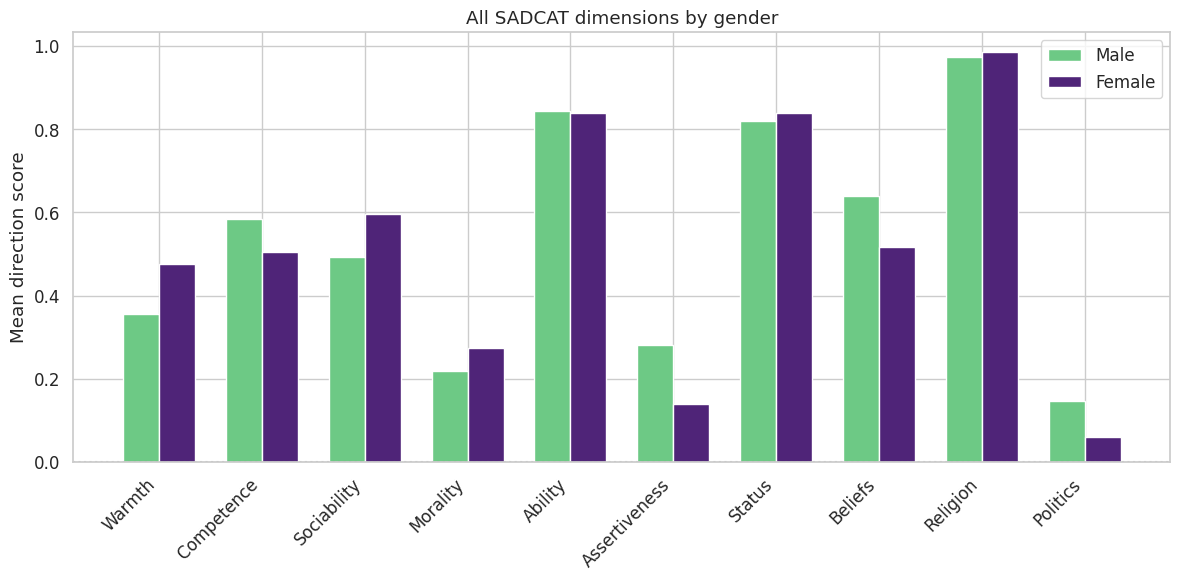


Dimension means:
gender         Female   Male
Warmth          0.477  0.357
Competence      0.505  0.584
Sociability     0.597  0.494
Morality        0.274  0.219
Ability         0.838  0.844
Assertiveness   0.141  0.281
Status          0.838  0.818
Beliefs         0.516  0.639
Religion        0.984  0.974
Politics        0.060  0.148


In [21]:
# ── 6a. All dimensions radar/bar comparison ──
dims = ["Warmth", "Competence", "Sociability", "Morality", "Ability",
        "Assertiveness", "Status", "Beliefs", "Religion", "Politics"]
dim_cols = [f"dirmean_{d}" for d in dims]

dim_means = dfa.groupby("gender")[dim_cols].mean().T
dim_means.index = dims

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(dims))
w = 0.35

bars_m = ax.bar(x - w/2, dim_means["Male"], w, label="Male", color=COLORS["Male"], edgecolor="white")
bars_f = ax.bar(x + w/2, dim_means["Female"], w, label="Female", color=COLORS["Female"], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(dims, rotation=45, ha="right")
ax.set_ylabel("Mean direction score")
ax.set_title("All SADCAT dimensions by gender")
ax.legend()
ax.axhline(0, color="gray", ls=":", alpha=0.5)

plt.tight_layout()
savefig(fig, "15_all_dimensions_gender")
plt.show()

print("\nDimension means:")
print(dim_means.round(3))

  Saved: ../figures/16_gender_gap_dimensions.png


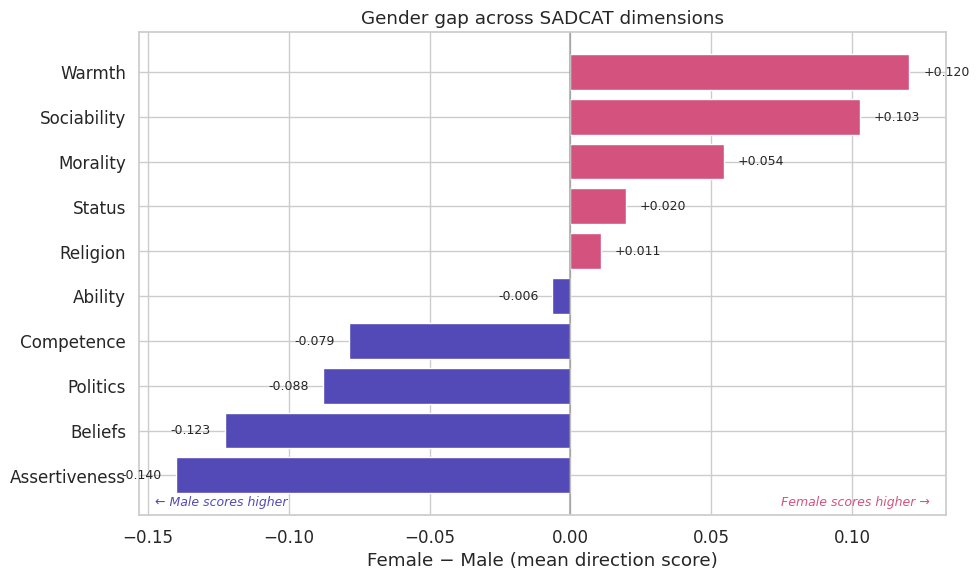

In [22]:
# ── 6b. Gender difference (F - M) for each dimension ──
diff = dim_means["Female"] - dim_means["Male"]
diff = diff.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#D4537E" if v > 0 else "#534AB7" for v in diff.values]
ax.barh(diff.index, diff.values, color=colors, edgecolor="white")
ax.axvline(0, color="gray", ls="-", alpha=0.5)
ax.set_xlabel("Female − Male (mean direction score)")
ax.set_title("Gender gap across SADCAT dimensions")

# Annotations
for i, (dim, val) in enumerate(zip(diff.index, diff.values)):
    ax.text(val + (0.005 if val > 0 else -0.005), i, f"{val:+.3f}",
           va="center", ha="left" if val > 0 else "right", fontsize=9)

ax.annotate("← Male scores higher", xy=(0.02, 0.02), xycoords="axes fraction",
           fontsize=9, color="#534AB7", style="italic")
ax.annotate("Female scores higher →", xy=(0.98, 0.02), xycoords="axes fraction",
           fontsize=9, color="#D4537E", style="italic", ha="right")

plt.tight_layout()
savefig(fig, "16_gender_gap_dimensions")
plt.show()

  Saved: ../figures/16b_dimension_correlation_matrix.png


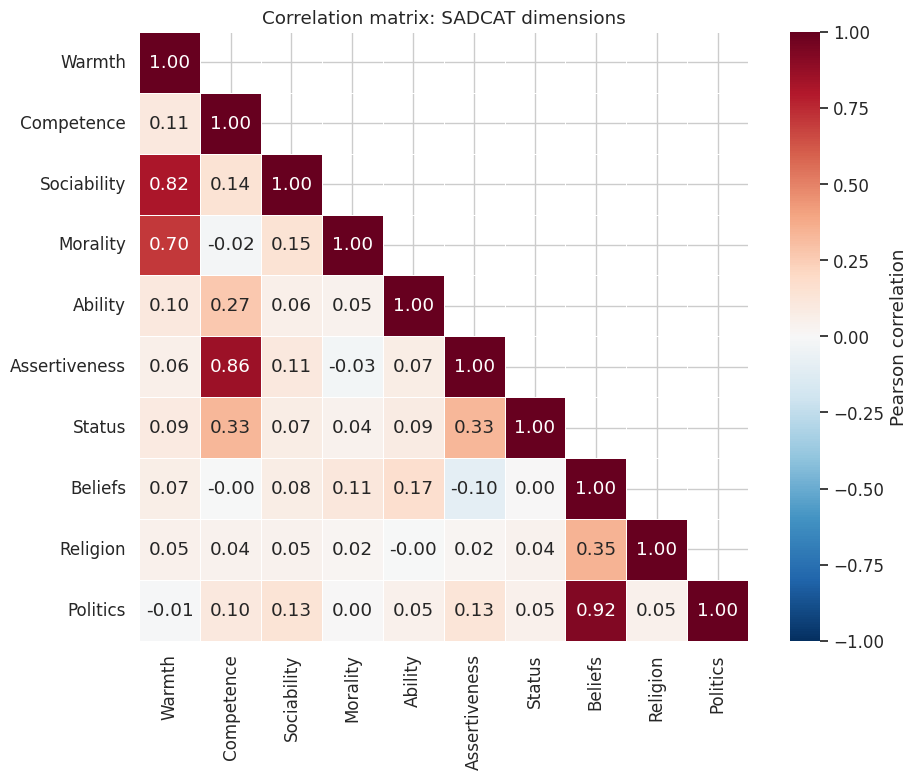

In [23]:
# -- 6c. Correlation matrix: all SADCAT dimensions --
corr_data = dfa[dim_cols].copy()
corr_data.columns = dims
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
           vmin=-1, vmax=1, linewidths=0.5, ax=ax, square=True,
           cbar_kws={"label": "Pearson correlation"})
ax.set_title("Correlation matrix: SADCAT dimensions")

plt.tight_layout()
savefig(fig, "16b_dimension_correlation_matrix")
plt.show()


## 7. Context × Gender: All Dimensions

  Saved: ../figures/17_heatmap_context_gender_dims.png


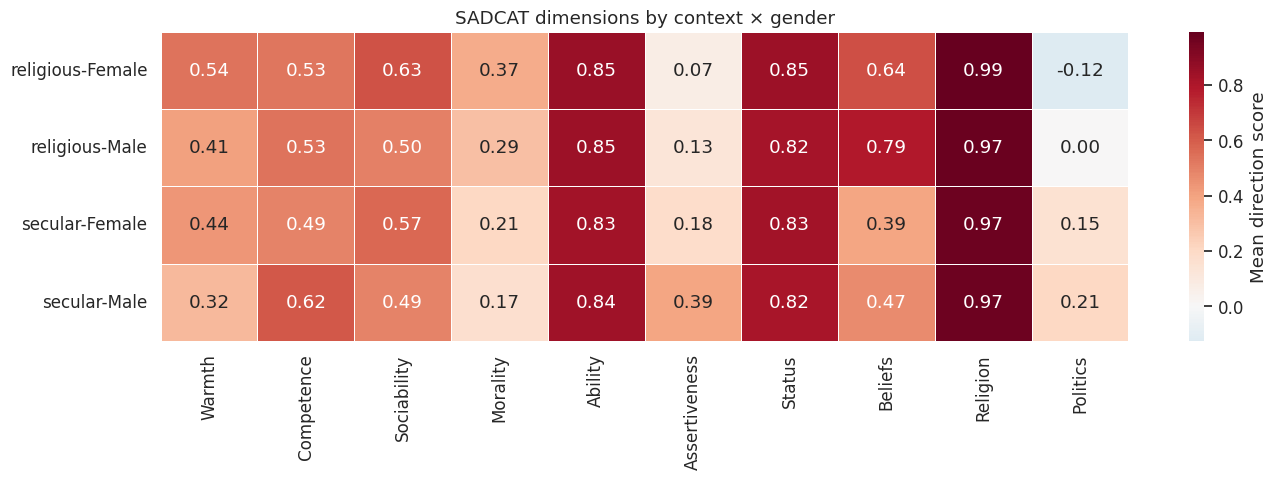

In [24]:
# ── 7a. Heatmap: all dimensions by context × gender ──
groups = dfa.groupby(["context", "gender"])[dim_cols].mean()
groups.columns = dims

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(groups, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
           linewidths=0.5, ax=ax, cbar_kws={"label": "Mean direction score"})
ax.set_title("SADCAT dimensions by context × gender")
ax.set_ylabel("")

plt.tight_layout()
savefig(fig, "17_heatmap_context_gender_dims")
plt.show()

  Saved: ../figures/18_religious_amplification_dimensions.png


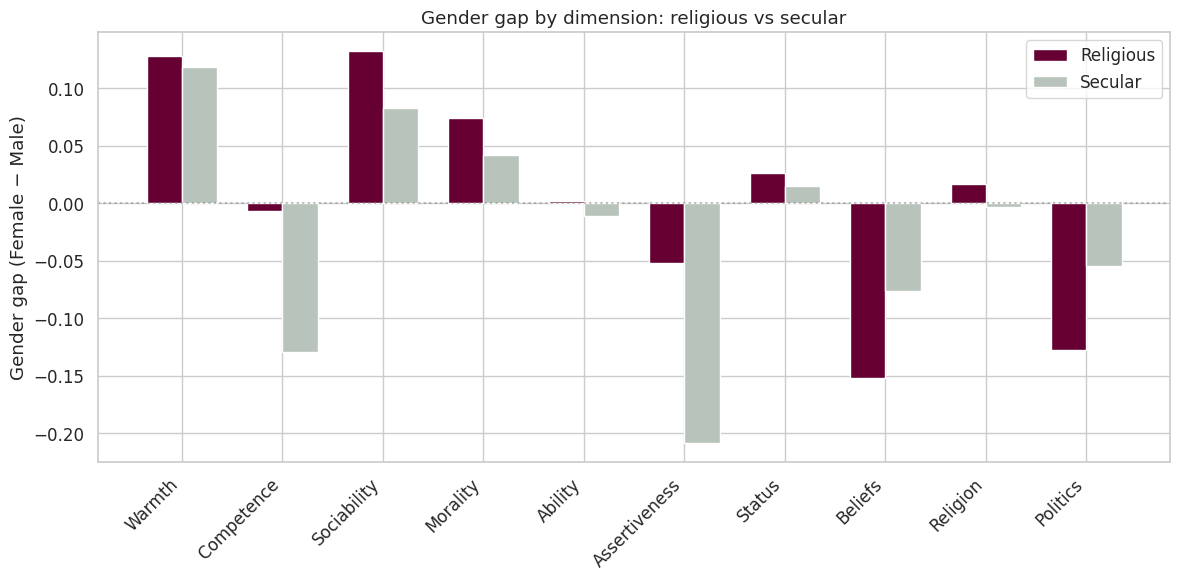

In [25]:
# ── 7b. Religious amplification: gender gap in each dimension ──
# For each dimension, compute (Female - Male) separately for religious and secular
gap_data = []
for ctx in ["religious", "secular"]:
    for dim, col in zip(dims, dim_cols):
        m_val = dfa[(dfa["context"]==ctx) & (dfa["gender"]=="Male")][col].mean()
        f_val = dfa[(dfa["context"]==ctx) & (dfa["gender"]=="Female")][col].mean()
        gap_data.append({"context": ctx, "dimension": dim, "gender_gap": f_val - m_val})

gap_df = pd.DataFrame(gap_data)
gap_pivot = gap_df.pivot(index="dimension", columns="context", values="gender_gap")
gap_pivot = gap_pivot.loc[dims]  # maintain order

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(dims))
w = 0.35

ax.bar(x - w/2, gap_pivot["religious"], w, label="Religious", color=CTX_COLORS["religious"], edgecolor="white")
ax.bar(x + w/2, gap_pivot["secular"], w, label="Secular", color=CTX_COLORS["secular"], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(dims, rotation=45, ha="right")
ax.set_ylabel("Gender gap (Female − Male)")
ax.set_title("Gender gap by dimension: religious vs secular")
ax.legend()
ax.axhline(0, color="gray", ls=":", alpha=0.5)

plt.tight_layout()
savefig(fig, "18_religious_amplification_dimensions")
plt.show()

## 8. Warmth × Competence Space: SCM Quadrant Plot

  Saved: ../figures/19_scm_quadrant_plot.png


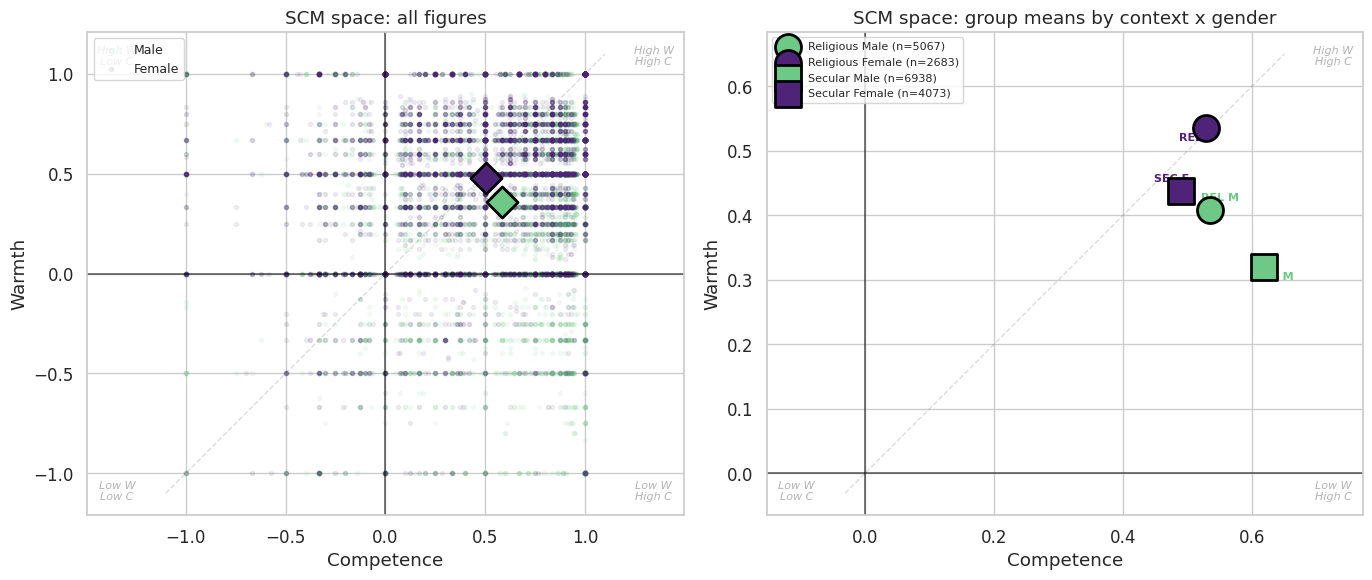

In [26]:
# -- 8a. SCM Quadrant Plot: Warmth x Competence with clear crosshair --
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: All figures scatter ---
for g in ["Male", "Female"]:
    sub = dfa[dfa["gender"]==g]
    axes[0].scatter(sub["dirmean_Competence"], sub["dirmean_Warmth"],
                   alpha=0.08, s=8, color=COLORS[g], label=g, rasterized=True)
    axes[0].scatter(sub["dirmean_Competence"].mean(), sub["dirmean_Warmth"].mean(),
                   s=250, color=COLORS[g], edgecolor="black", lw=2, zorder=5, marker="D")

# Crosshair at origin
for ax in axes:
    ax.axhline(0, color="black", ls="-", lw=1.2, alpha=0.6, zorder=1)
    ax.axvline(0, color="black", ls="-", lw=1.2, alpha=0.6, zorder=1)

# Quadrant labels
q_labels = {
    "High W\nHigh C": (0.95, 0.95),
    "High W\nLow C": (0.05, 0.95),
    "Low W\nHigh C": (0.95, 0.05),
    "Low W\nLow C": (0.05, 0.05),
}
for label, (xf, yf) in q_labels.items():
    axes[0].text(xf, yf, label, transform=axes[0].transAxes,
               fontsize=8, color="gray", alpha=0.6, ha="center", va="center", style="italic")

axes[0].set_xlabel("Competence")
axes[0].set_ylabel("Warmth")
axes[0].set_title("SCM space: all figures")
axes[0].legend(loc="upper left", fontsize=9)

# --- Panel 2: Group means by context x gender (non-overlapping) ---
markers = {"religious": "o", "secular": "s"}

group_pts = []
for ctx in ["religious", "secular"]:
    for g in ["Male", "Female"]:
        sub = dfa[(dfa["context"]==ctx) & (dfa["gender"]==g)]
        group_pts.append({
            "ctx": ctx, "gender": g,
            "comp": sub["dirmean_Competence"].mean(),
            "warm": sub["dirmean_Warmth"].mean(),
            "n": len(sub)
        })

for pt in group_pts:
    axes[1].scatter(pt["comp"], pt["warm"],
                   s=350, color=COLORS[pt["gender"]],
                   marker=markers[pt["ctx"]], edgecolor="black", lw=2, zorder=5,
                   label=f'{pt["ctx"].capitalize()} {pt["gender"]} (n={pt["n"]})')

# Text labels offset to avoid overlap
offsets = [
    (0.015, 0.015),
    (-0.015, -0.02),
    (0.015, -0.02),
    (-0.015, 0.015),
]
for pt, (dx, dy) in zip(group_pts, offsets):
    axes[1].annotate(f'{pt["ctx"][:3].upper()} {pt["gender"][0]}',
                    xy=(pt["comp"], pt["warm"]),
                    xytext=(pt["comp"]+dx, pt["warm"]+dy),
                    fontsize=8, fontweight="bold", color=COLORS[pt["gender"]],
                    ha="center")

for label, (xf, yf) in q_labels.items():
    axes[1].text(xf, yf, label, transform=axes[1].transAxes,
               fontsize=8, color="gray", alpha=0.6, ha="center", va="center", style="italic")

axes[1].set_xlabel("Competence")
axes[1].set_ylabel("Warmth")
axes[1].set_title("SCM space: group means by context x gender")
axes[1].legend(fontsize=8, loc="upper left")

# Diagonal (W=C line)
for ax in axes:
    lims_all = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
               max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims_all, lims_all, "k--", alpha=0.15, lw=1)
    ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()
savefig(fig, "19_scm_quadrant_plot")
plt.show()


## 9. Animal Presence (H3 preview)

   is_fauna    context  gender     n  asymmetry  warmth  competence  \
0         0  religious  Female  1683     -0.019   0.527       0.536   
1         0  religious    Male  3160     -0.122   0.403       0.516   
2         0    secular  Female  2230     -0.085   0.432       0.503   
3         0    secular    Male  3234     -0.281   0.367       0.640   
4         1  religious  Female  1000      0.026   0.550       0.515   
5         1  religious    Male  1907     -0.158   0.415       0.567   
6         1    secular  Female  1843     -0.044   0.445       0.473   
7         1    secular    Male  3704     -0.331   0.278       0.600   

      fauna_label  
0       No animal  
1       No animal  
2       No animal  
3       No animal  
4  Animal present  
5  Animal present  
6  Animal present  
7  Animal present  
  Saved: ../figures/20_h3_animal_asymmetry.png


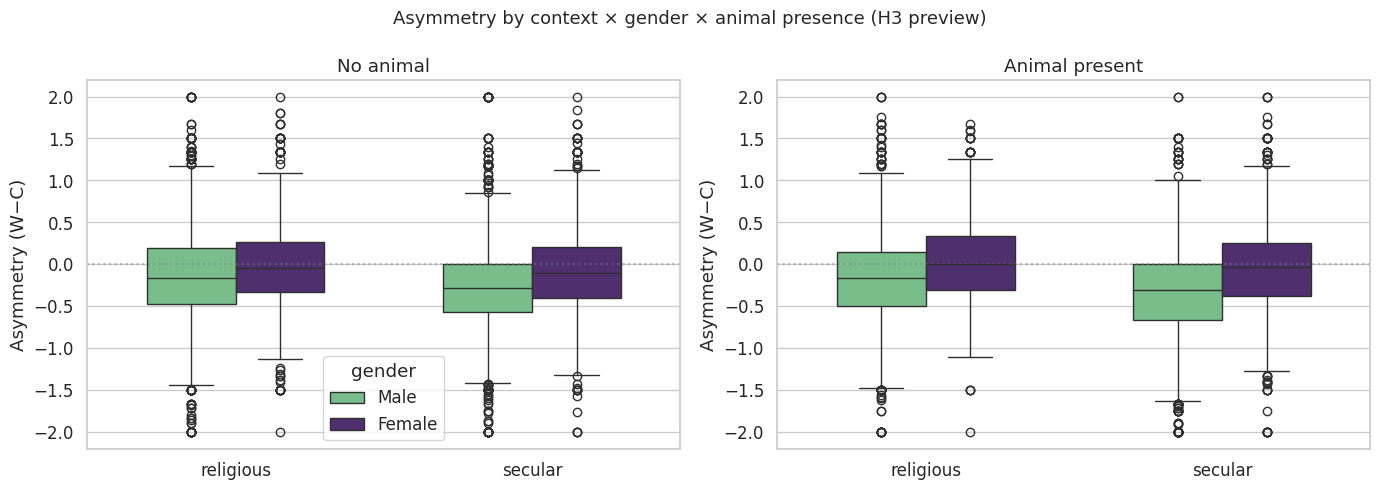

In [27]:
# ── 9a. Asymmetry by gender × religious × animal presence ──
animal_data = dfa.groupby(["is_fauna", "context", "gender"]).agg(
    n=("cat_no", "count"),
    asymmetry=("asymmetry", "mean"),
    warmth=("dirmean_Warmth", "mean"),
    competence=("dirmean_Competence", "mean"),
).reset_index()

animal_data["fauna_label"] = animal_data["is_fauna"].map({1: "Animal present", 0: "No animal"})
print(animal_data.round(3))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, fauna_val in enumerate([0, 1]):
    fauna_label = "No animal" if fauna_val == 0 else "Animal present"
    sub = dfa[dfa["is_fauna"] == fauna_val]
    
    sns.boxplot(data=sub, x="context", y="asymmetry", hue="gender",
               palette=COLORS, hue_order=["Male", "Female"],
               order=["religious", "secular"], width=0.6, ax=axes[i])
    axes[i].set_title(f"{fauna_label}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Asymmetry (W−C)")
    axes[i].axhline(0, color="gray", ls=":", alpha=0.5)
    if i > 0:
        axes[i].get_legend().remove()

fig.suptitle("Asymmetry by context × gender × animal presence (H3 preview)", fontsize=13)
plt.tight_layout()
savefig(fig, "20_h3_animal_asymmetry")
plt.show()

## 10. Temporal Analysis: Trends Across Centuries

In [28]:
# -- 10a. Clean century column and check distribution --
# Century column is already in format "17th c.", "18th c." etc.
dfa_t = dfa.copy()

# Parse the "Xth c." format to integer for ordering
import re

def parse_century_str(val):
    if pd.isna(val) or val is None or str(val).strip() == "":
        return None
    match = re.match(r"(\d+)", str(val).strip())
    if match:
        return int(match.group(1))
    return None

dfa_t["century_num"] = dfa_t["century"].apply(parse_century_str)

print(f"Century coverage: {dfa_t['century_num'].notna().sum()} / {len(dfa_t)} ({dfa_t['century_num'].notna().mean()*100:.1f}%)")
print(f"\nRaw century values:")
print(dfa_t["century"].value_counts().sort_index())
print(f"\nParsed century_num distribution:")
print(dfa_t["century_num"].value_counts().sort_index())

# Filter to figures with valid century
dfa_t = dfa_t[dfa_t["century_num"].notna()].copy()

# Create sorted century label for plotting
century_order = sorted(dfa_t["century_num"].unique())
century_labels = {n: f"{int(n)}th c." for n in century_order}
dfa_t["century_label"] = dfa_t["century_num"].map(century_labels)

print(f"\nFigures with valid century: {len(dfa_t)}")


Century coverage: 18761 / 18761 (100.0%)

Raw century values:
century
12th c.      70
13th c.      25
14th c.      37
15th c.     645
16th c.    2230
17th c.    7916
18th c.    2831
19th c.    4230
20th c.     777
Name: count, dtype: int64

Parsed century_num distribution:
century_num
12      70
13      25
14      37
15     645
16    2230
17    7916
18    2831
19    4230
20     777
Name: count, dtype: int64

Figures with valid century: 18761


  Saved: ../figures/21_temporal_figure_counts.png


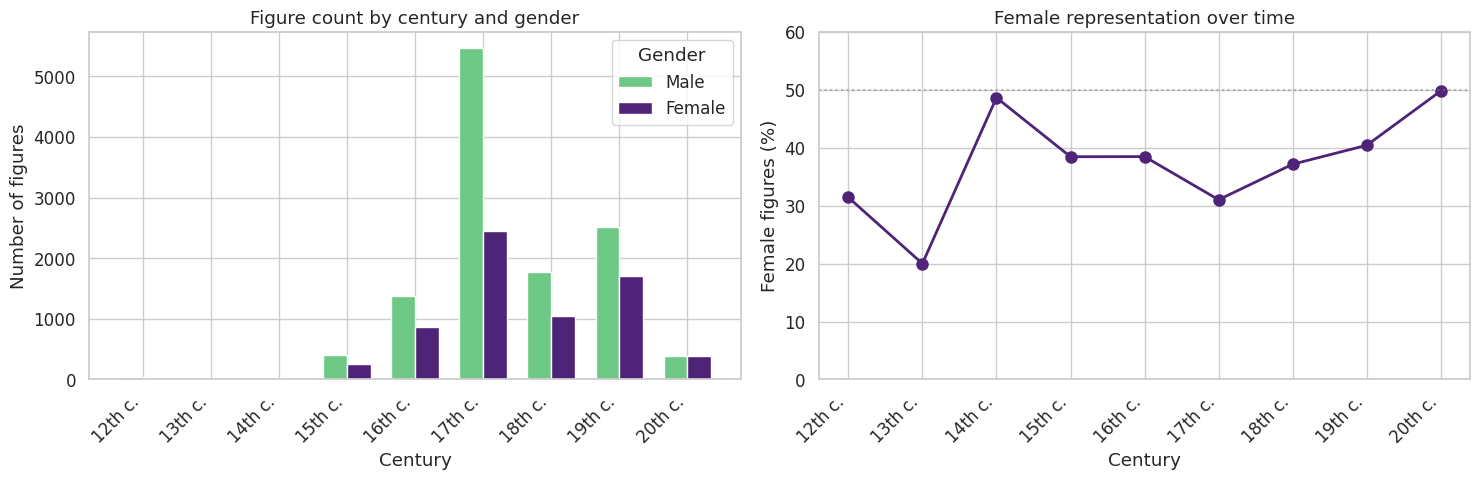

In [29]:
# -- 10b. Figure count by century and gender --
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ct_gender = dfa_t.groupby(["century_num", "gender"]).size().unstack(fill_value=0)
x_labels = [century_labels.get(c, str(int(c))) for c in ct_gender.index]

x = np.arange(len(ct_gender.index))
w = 0.35
axes[0].bar(x - w/2, ct_gender["Male"], w, label="Male", color=COLORS["Male"], edgecolor="white")
axes[0].bar(x + w/2, ct_gender["Female"], w, label="Female", color=COLORS["Female"], edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0].set_xlabel("Century")
axes[0].set_ylabel("Number of figures")
axes[0].set_title("Figure count by century and gender")
axes[0].legend(title="Gender")

# Female proportion by century
female_pct = ct_gender["Female"] / ct_gender.sum(axis=1) * 100
axes[1].plot(x, female_pct.values, "o-", color=COLORS["Female"], lw=2, markersize=8)
axes[1].axhline(50, color="gray", ls=":", alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_xlabel("Century")
axes[1].set_ylabel("Female figures (%)")
axes[1].set_title("Female representation over time")
axes[1].set_ylim(0, 60)

plt.tight_layout()
savefig(fig, "21_temporal_figure_counts")
plt.show()


  Saved: ../figures/22_temporal_wc_trends.png


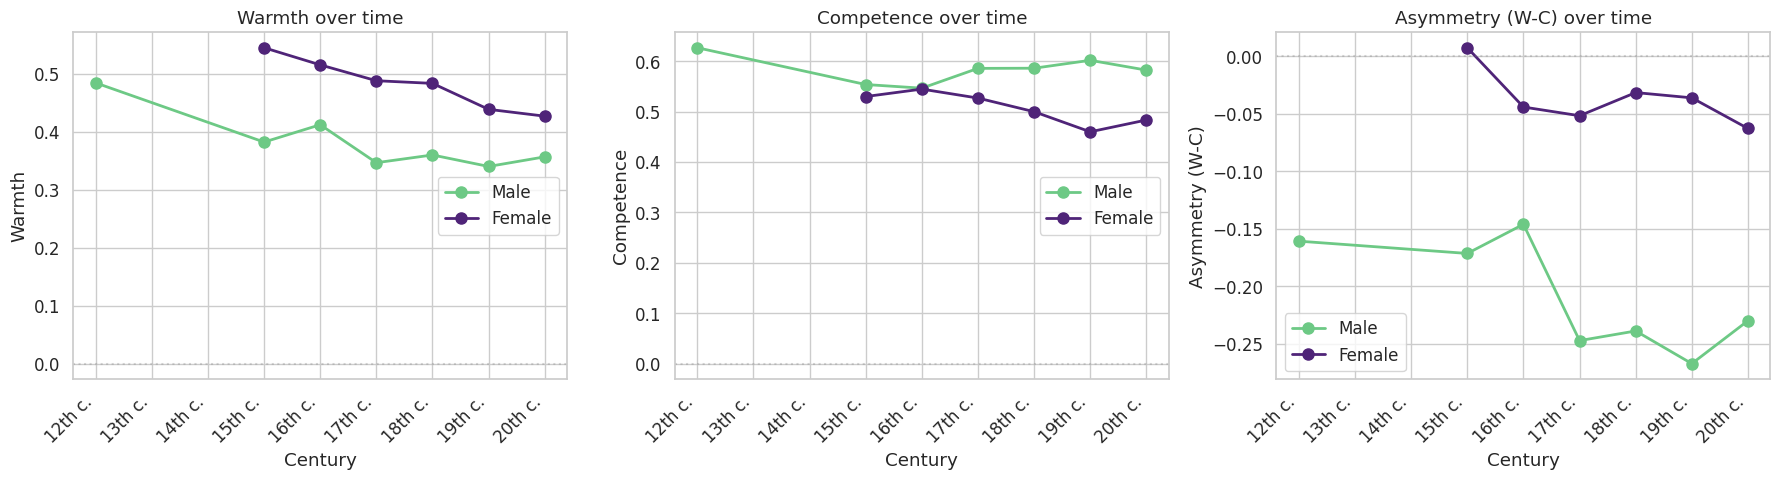

In [30]:
# -- 10c. Warmth and Competence trends over centuries by gender --
temporal = dfa_t.groupby(["century_num", "gender"]).agg(
    n=("cat_no", "count"),
    warmth=("dirmean_Warmth", "mean"),
    competence=("dirmean_Competence", "mean"),
    asymmetry=("asymmetry", "mean"),
).reset_index()

# Filter to centuries with enough data (at least 30 figures per group)
temporal = temporal[temporal["n"] >= 30]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, title) in enumerate([("warmth", "Warmth"), ("competence", "Competence"),
                                   ("asymmetry", "Asymmetry (W-C)")]):
    for g in ["Male", "Female"]:
        sub = temporal[temporal["gender"] == g].sort_values("century_num")
        x_pos = [list(century_order).index(c) for c in sub["century_num"] if c in century_order]
        y_vals = sub[sub["century_num"].isin(century_order)][col].values
        axes[i].plot(x_pos, y_vals, "o-", color=COLORS[g], lw=2, markersize=8, label=g)
    axes[i].set_xticks(range(len(century_order)))
    axes[i].set_xticklabels([century_labels[c] for c in century_order], rotation=45, ha="right")
    axes[i].set_xlabel("Century")
    axes[i].set_ylabel(title)
    axes[i].set_title(f"{title} over time")
    axes[i].legend()
    axes[i].axhline(0, color="gray", ls=":", alpha=0.3)

plt.tight_layout()
savefig(fig, "22_temporal_wc_trends")
plt.show()


  Saved: ../figures/23_temporal_gender_gap.png


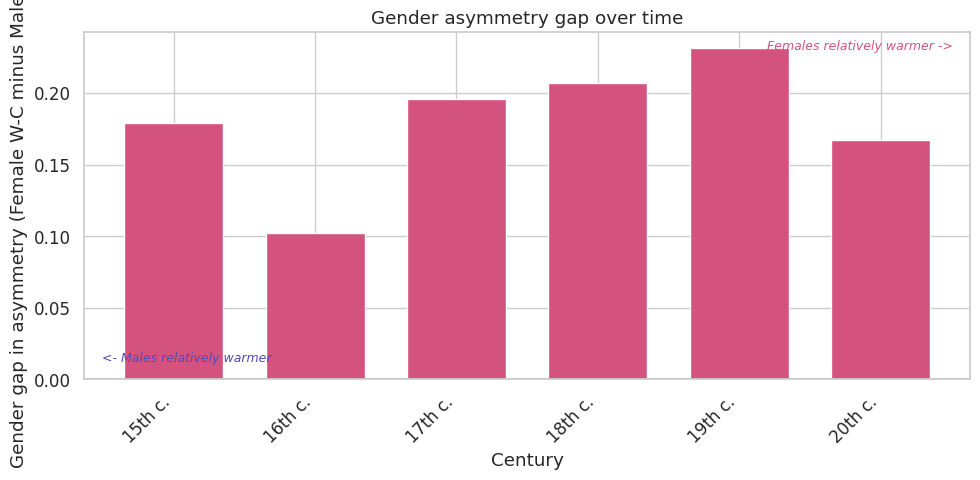

In [31]:
# -- 10d. Gender asymmetry gap over time --
asym_wide = temporal.pivot(index="century_num", columns="gender", values="asymmetry")
asym_wide["gender_gap"] = asym_wide["Female"] - asym_wide["Male"]
asym_wide = asym_wide.dropna(subset=["gender_gap"]).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = range(len(asym_wide))
x_labs = [century_labels.get(c, str(int(c))) for c in asym_wide.index]
colors_bar = ["#D4537E" if v > 0 else "#534AB7" for v in asym_wide["gender_gap"]]

ax.bar(x_pos, asym_wide["gender_gap"], color=colors_bar, edgecolor="white", width=0.7)
ax.axhline(0, color="gray", ls="-", alpha=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labs, rotation=45, ha="right")
ax.set_xlabel("Century")
ax.set_ylabel("Gender gap in asymmetry (Female W-C minus Male W-C)")
ax.set_title("Gender asymmetry gap over time")

ax.annotate("Females relatively warmer ->", xy=(0.98, 0.95), xycoords="axes fraction",
           fontsize=9, color="#D4537E", style="italic", ha="right")
ax.annotate("<- Males relatively warmer", xy=(0.02, 0.05), xycoords="axes fraction",
           fontsize=9, color="#534AB7", style="italic", ha="left")

plt.tight_layout()
savefig(fig, "23_temporal_gender_gap")
plt.show()


  Saved: ../figures/24_temporal_context_trends.png


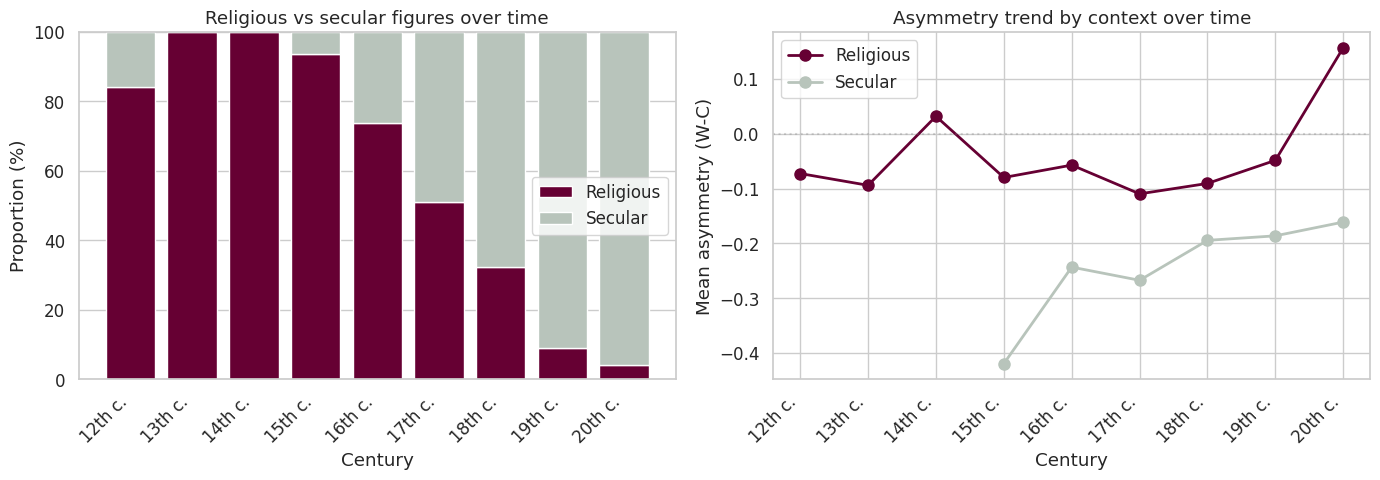

In [32]:
# -- 10e. Religious vs secular proportion over time --
ctx_time = dfa_t.groupby(["century_num", "context"]).size().unstack(fill_value=0).sort_index()
ctx_pct = ctx_time.div(ctx_time.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = range(len(ctx_pct))
x_labs = [century_labels.get(c, str(int(c))) for c in ctx_pct.index]

if "religious" in ctx_pct.columns and "secular" in ctx_pct.columns:
    axes[0].bar(x_pos, ctx_pct["religious"], label="Religious",
               color=CTX_COLORS["religious"], edgecolor="white")
    axes[0].bar(x_pos, ctx_pct["secular"], bottom=ctx_pct["religious"], label="Secular",
               color=CTX_COLORS["secular"], edgecolor="white")
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(x_labs, rotation=45, ha="right")
    axes[0].set_xlabel("Century")
    axes[0].set_ylabel("Proportion (%)")
    axes[0].set_title("Religious vs secular figures over time")
    axes[0].legend(loc="center right")
    axes[0].set_ylim(0, 100)

# Asymmetry by context over time
for ctx, color in CTX_COLORS.items():
    ctx_temporal = dfa_t[dfa_t["context"] == ctx].groupby("century_num")["asymmetry"].mean()
    ctx_counts = dfa_t[dfa_t["context"] == ctx].groupby("century_num").size()
    valid = ctx_counts[ctx_counts >= 20].index
    ctx_temporal = ctx_temporal[ctx_temporal.index.isin(valid)].sort_index()
    x_pos_ctx = [list(century_order).index(c) for c in ctx_temporal.index if c in century_order]
    y_vals = [ctx_temporal[c] for c in ctx_temporal.index if c in century_order]
    axes[1].plot(x_pos_ctx, y_vals, "o-", color=color, lw=2, markersize=8, label=ctx.capitalize())

axes[1].set_xticks(range(len(century_order)))
axes[1].set_xticklabels([century_labels[c] for c in century_order], rotation=45, ha="right")
axes[1].set_xlabel("Century")
axes[1].set_ylabel("Mean asymmetry (W-C)")
axes[1].set_title("Asymmetry trend by context over time")
axes[1].legend()
axes[1].axhline(0, color="gray", ls=":", alpha=0.3)

plt.tight_layout()
savefig(fig, "24_temporal_context_trends")
plt.show()


  Saved: ../figures/25_temporal_dimensions_heatmap.png


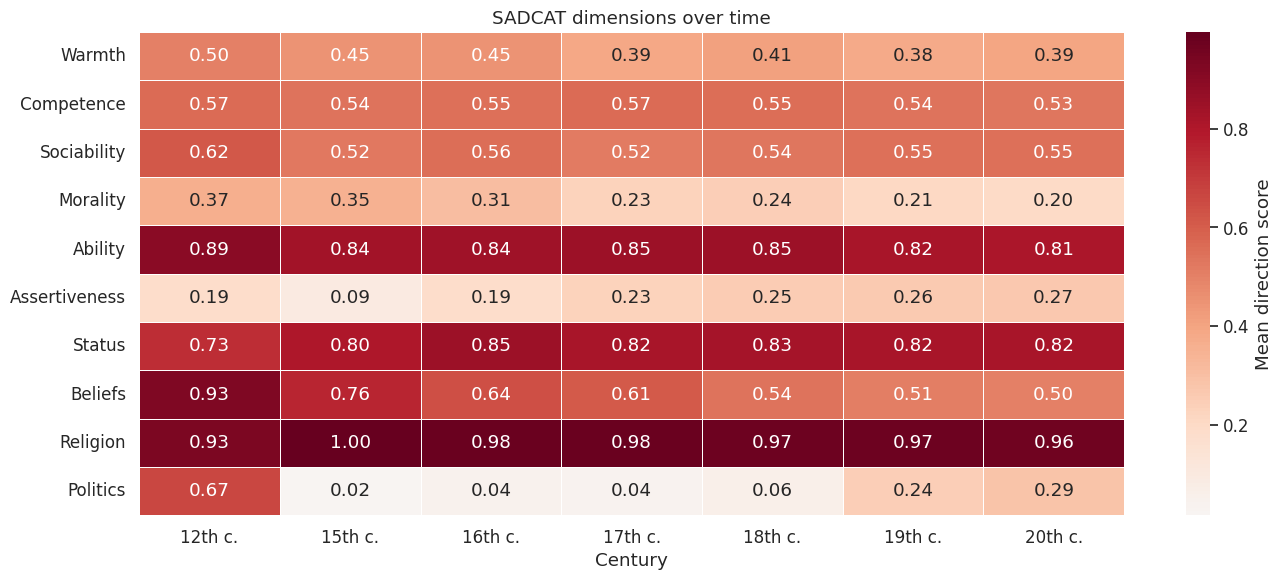

In [33]:
# -- 10f. All dimensions over time (heatmap) --
dims_temporal = dfa_t.groupby("century_num")[dim_cols].mean()
dims_temporal.columns = dims

# Filter to centuries with enough data
century_counts = dfa_t.groupby("century_num").size()
valid_centuries = century_counts[century_counts >= 50].index
dims_temporal = dims_temporal.loc[dims_temporal.index.isin(valid_centuries)].sort_index()

# Rename index to century labels
dims_temporal.index = [century_labels.get(c, str(int(c))) for c in dims_temporal.index]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(dims_temporal.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
           linewidths=0.5, ax=ax, cbar_kws={"label": "Mean direction score"})
ax.set_xlabel("Century")
ax.set_ylabel("")
ax.set_title("SADCAT dimensions over time")

plt.tight_layout()
savefig(fig, "25_temporal_dimensions_heatmap")
plt.show()


## 11. Summary Statistics for Paper

In [ ]:
# -- 11. Full summary table --
import os

full_summary = dfa.groupby(["context", "gender"]).agg(
    n=("cat_no", "count"),
    n_artworks=("cat_no", "nunique"),
    coverage=("coverage_pct", "mean"),
    warmth=("dirmean_Warmth", "mean"),
    warmth_sd=("dirmean_Warmth", "std"),
    competence=("dirmean_Competence", "mean"),
    competence_sd=("dirmean_Competence", "std"),
    asymmetry=("asymmetry", "mean"),
    asymmetry_sd=("asymmetry", "std"),
    sociability=("dirmean_Sociability", "mean"),
    morality=("dirmean_Morality", "mean"),
    ability=("dirmean_Ability", "mean"),
    assertiveness=("dirmean_Assertiveness", "mean"),
    status=("dirmean_Status", "mean"),
).round(3)

print("Full summary (for paper tables):")
full_summary.to_csv("../tables/summary_context_gender.csv")
full_summary


Full summary (for paper tables):


n  n_artworks  coverage  warmth  warmth_sd  competence  \
context   gender                                                              
religious Female  2683        1477    56.823   0.536      0.321       0.528   
          Male    5067        2016    55.595   0.408      0.392       0.535   
secular   Female  4073        2351    53.603   0.438      0.406       0.489   
          Male    6938        3082    53.842   0.319      0.433       0.619   

                  competence_sd  asymmetry  asymmetry_sd  sociability  \
context   gender                                                        
religious Female          0.422     -0.002         0.488        0.632   
          Male            0.437     -0.135         0.553        0.500   
secular   Female          0.434     -0.067         0.523        0.572   
          Male            0.386     -0.308         0.535        0.489   

                  morality  ability  assertiveness  status  
context   gender                                            
religious Female     0.369    0.853          0.074   0.848  
          Male       0.294    0.852          0.126   0.822  
secular   Female     0.209    0.828          0.181   0.830  
          Male       0.167    0.839          0.389   0.816